<a href="https://colab.research.google.com/github/daniel-barona/Analisis_de_datos_sipsa/blob/main/00_descargas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026-

# 00_descargas
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa el primer paso crucial en nuestro proceso de ciencia de datos: la obtención y almacenamiento de datos crudos. El principio fundamental aquí es preservar los datos en su estado original, sin modificaciones, para garantizar la reproducibilidad del análisis y mantener una referencia histórica confiable.

**Propósito:** Establecer el punto de partida del análisis mediante la recopilación y almacenamiento de datos crudos de múltiples fuentes, manteniendo la integridad y trazabilidad de la información original.

**Tareas habituales:**
- Configuración de conexiones a bases de datos SQL y ejecución de consultas
- Implementación de web scraping para extracción de datos de páginas web
- Desarrollo de scripts RPA (Robotic Process Automation) para automatizar descargas
- Autenticación y descarga de datos desde APIs
- Verificación de integridad de archivos descargados
- Documentación de fuentes, timestamps y métodos de obtención
- Establecimiento de estructura de carpetas para datos crudos
- Implementación de control de versiones para datos cuando sea aplicable

In [ ]:
!rm -rf /content/proyecto_ciencia_datos

#EDA y CONSOLIDACION DEL DATASET

In [1]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 171 (delta 43), reused 14 (delta 14), pack-reused 115 (from 1)
Receiving objects: 100% (171/171), 21.04 MiB | 26.25 MiB/s, done.
Resolving deltas: 100% (93/93), done.


In [2]:
from pathlib import Path

In [3]:
folder_path = Path("/content/proyecto_ciencia_datos/data/Descargas")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 10
series-historicas-precios-mayoristas-2021.xlsx
series-historicas-precios-mayoristas-2020.xlsx
anex-SIPSA-SerieHistoricaMayorista-Dic2023.xlsx
series-historicas-precios-mayoristas-2022.xlsx
series-historicas-precios-mayoristas-2019.xlsx
series-historicas-precios-mayoristas-2018.xlsx
anex-SIPSA-SerieHistoricaMayorista-2025 (2).xlsx
anex-SIPSA-SerieHistoricaMayorista-2026.xlsx
series-historicas-precios-mayoristas.xlsx
anex-SIPSA-SerieHistoricaMayorista-2024.xlsx


In [4]:
import os
import pandas as pd

###ENTENDER COMO VIENEN LOS ARCHIVOS

In [5]:
folder_path = "/content/proyecto_ciencia_datos/data/Descargas"
files = [
    "series-historicas-precios-mayoristas-2019.xlsx",
    "anex-SIPSA-SerieHistoricaMayorista-2024.xlsx",
    "series-historicas-precios-mayoristas-2021.xlsx",
    "anex-SIPSA-SerieHistoricaMayorista-2026.xlsx",
    "anex-SIPSA-SerieHistoricaMayorista-2025 (2).xlsx",
    "series-historicas-precios-mayoristas-2022.xlsx",
    "series-historicas-precios-mayoristas-2020.xlsx",
    "series-historicas-precios-mayoristas-2018.xlsx",
    "anex-SIPSA-SerieHistoricaMayorista-Dic2023.xlsx",
    "series-historicas-precios-mayoristas.xlsx",
]


In [6]:
hojas_excluir = [
    "indice",
    "índice",
    "fuentes",
    "cpc"
]
for file in files:

    file_path = os.path.join(folder_path, file)
    try:
        xls = pd.ExcelFile(file_path)
        print("\n" + "="*80)
        print(file)
        print("Hojas encontradas:")
        print(xls.sheet_names)
        hojas_datos = [
            hoja
            for hoja in xls.sheet_names
            if hoja.strip().lower() not in hojas_excluir
        ]
        print("\nHojas que se analizarán:")
        print(hojas_datos)
    except Exception as e:
        print(f"Error en {file}: {e}")


series-historicas-precios-mayoristas-2019.xlsx
Hojas encontradas:
['Índice', 'Ene 19', 'Feb 19', 'Mar 19', 'Abr 19', 'May 19', 'Jun 19', 'Jul 19', 'Ago 19', 'Sep 19', 'Oct 19', 'Nov 19', 'Dic 19']

Hojas que se analizarán:
['Ene 19', 'Feb 19', 'Mar 19', 'Abr 19', 'May 19', 'Jun 19', 'Jul 19', 'Ago 19', 'Sep 19', 'Oct 19', 'Nov 19', 'Dic 19']

anex-SIPSA-SerieHistoricaMayorista-2024.xlsx
Hojas encontradas:
['2024']

Hojas que se analizarán:
['2024']

series-historicas-precios-mayoristas-2021.xlsx
Hojas encontradas:
['Índice', 'Ene 21', 'Feb 21', 'Mar 21', 'Abr 21', 'May 21', 'Jun 21', 'Jul 21', 'Ago 21', 'Sep 21', 'Oct 21', 'Nov 21', 'Dic 21']

Hojas que se analizarán:
['Ene 21', 'Feb 21', 'Mar 21', 'Abr 21', 'May 21', 'Jun 21', 'Jul 21', 'Ago 21', 'Sep 21', 'Oct 21', 'Nov 21', 'Dic 21']

anex-SIPSA-SerieHistoricaMayorista-2026.xlsx
Hojas encontradas:
['2026', 'Fuentes', 'CPC']

Hojas que se analizarán:
['2026']

anex-SIPSA-SerieHistoricaMayorista-2025 (2).xlsx
Hojas encontradas:
['202

###Purgacion de archivos desde el 2019-2023

In [7]:
folder_path = "/content/proyecto_ciencia_datos/data/Descargas"
output_path = "/content/proyecto_ciencia_datos/data/Unificados"
#creamos la carpeta en caso de no existir
os.makedirs(output_path, exist_ok=True)
files = [
"series-historicas-precios-mayoristas-2019.xlsx",
"series-historicas-precios-mayoristas-2020.xlsx",
"series-historicas-precios-mayoristas-2021.xlsx",
"series-historicas-precios-mayoristas-2022.xlsx",
"anex-SIPSA-SerieHistoricaMayorista-Dic2023.xlsx"
]
for file in files:
  print("\n" + "=" * 80)
  print(f"Procesando: {file}")
  file_path = os.path.join(folder_path, file)
  try:
    xls = pd.ExcelFile(file_path)
    hojas_datos = [
        hoja
        for hoja in xls.sheet_names
        if hoja.strip().lower() not in ["indice", "índice"]
    ]
    dfs = []
    for hoja in hojas_datos:
      print(f" Leyendo hoja: {hoja}")
      df = pd.read_excel(
          file_path,
          sheet_name=hoja,
          skiprows=6
      )
      df = df.dropna(axis=1, how="all")
      df = df.dropna(how="all")
      df = df[
          ~df.astype(str)
          .apply(
            lambda fila: fila.str.contains(
                "* Los precios reportados",
                case=False,
                na=False,
                regex=False
            ).any(),
            axis=1
          )
      ]
      df["MES_AÑO"] = hoja
      dfs.append(df)
    df_unificado = pd.concat(
        dfs,
        ignore_index=True
    )
    nombre_salida = file.replace(
        ".xlsx",
        "_unificado.xlsx"
    )
    ruta_salida = os.path.join(
        output_path,
        nombre_salida
    )
    df_unificado.to_excel(
        ruta_salida,
        index=False
    )
    print(f"✅ Archivo generado: {nombre_salida}")
    print(f"✅ Filas: {df_unificado.shape[0]:,}")
    print(f"✅ Columnas: {df_unificado.shape[1]}")
  except Exception as e:
    print(f"❌ Error en {file}")
    print(e)
  print("\nProceso finalizado.")


Procesando: series-historicas-precios-mayoristas-2019.xlsx
 Leyendo hoja: Ene 19
 Leyendo hoja: Feb 19
 Leyendo hoja: Mar 19
 Leyendo hoja: Abr 19
 Leyendo hoja: May 19
 Leyendo hoja: Jun 19
 Leyendo hoja: Jul 19
 Leyendo hoja: Ago 19
 Leyendo hoja: Sep 19
 Leyendo hoja: Oct 19
 Leyendo hoja: Nov 19
 Leyendo hoja: Dic 19
✅ Archivo generado: series-historicas-precios-mayoristas-2019_unificado.xlsx
✅ Filas: 56,626
✅ Columnas: 6

Proceso finalizado.

Procesando: series-historicas-precios-mayoristas-2020.xlsx
 Leyendo hoja: Ene 20
 Leyendo hoja: Feb 20
 Leyendo hoja: Mar 20
 Leyendo hoja: Abr 20
 Leyendo hoja: May 20
 Leyendo hoja: Jun 20
 Leyendo hoja: Jul 20
 Leyendo hoja: Ago 20
 Leyendo hoja: Sep 20
 Leyendo hoja: Oct 20
 Leyendo hoja: Nov 20
 Leyendo hoja: Dic 20
✅ Archivo generado: series-historicas-precios-mayoristas-2020_unificado.xlsx
✅ Filas: 55,716
✅ Columnas: 6

Proceso finalizado.

Procesando: series-historicas-precios-mayoristas-2021.xlsx
 Leyendo hoja: Ene 21
 Leyendo hoja:

###Purgacion de archivo del 2013-3017

In [8]:
folder_path = "/content/proyecto_ciencia_datos/data/Descargas"
output_path = "/content/proyecto_ciencia_datos/data/Unificados"
os.makedirs(output_path, exist_ok=True)
archivo = "series-historicas-precios-mayoristas.xlsx"
ruta_archivo = os.path.join(folder_path, archivo)
xls = pd.ExcelFile(ruta_archivo)
hojas = [
    hoja
    for hoja in xls.sheet_names
    if hoja.strip().lower() not in ["indice", "índice"]
]

dfs = []

for hoja in hojas:

    print(f"Leyendo hoja: {hoja}")

    df = pd.read_excel(
        ruta_archivo,
        sheet_name=hoja,
        skiprows=9
    )

    df = df.dropna(axis=1, how="all")
    df = df.dropna(how="all")
    df = df.rename(columns={"Fuente": "Mercado"})
    df["MES_AÑO"] = hoja

    dfs.append(df)

# ← Aquí termina el for

df_final = pd.concat(
    dfs,
    ignore_index=True
)

ruta_salida = os.path.join(
    output_path,
    "series-historicas-precios-mayoristas_unificado.xlsx"
)

df_final.to_excel(
    ruta_salida,
    index=False
)

print("\nProceso finalizado.")
print(f"Filas: {df_final.shape[0]:,}")
print(f"Columnas: {df_final.shape[1]}")
print(f"Archivo guardado en:\n{ruta_salida}")

Leyendo hoja: 1.1
Leyendo hoja: 1.2
Leyendo hoja: 1.3
Leyendo hoja: 1.4
Leyendo hoja: 1.5

Proceso finalizado.
Filas: 281,386
Columnas: 6
Archivo guardado en:
/content/proyecto_ciencia_datos/data/Unificados/series-historicas-precios-mayoristas_unificado.xlsx


###PURGACION DE ARCHIVOS 2024 2025


In [9]:
folder_path = "/content/proyecto_ciencia_datos/data/Descargas"
output_path = "/content/proyecto_ciencia_datos/data/Unificados"

os.makedirs(output_path, exist_ok=True)

files = [
    "anex-SIPSA-SerieHistoricaMayorista-2024.xlsx",
    "anex-SIPSA-SerieHistoricaMayorista-2025 (2).xlsx",
]

for file in files:
    print("\n" + "=" * 80)
    print(f"Procesando: {file}")
    ruta_archivo = os.path.join(folder_path, file)
    try:
        xls = pd.ExcelFile(ruta_archivo)
        dfs = []
        for hoja in xls.sheet_names:
            if hoja.strip().lower() in ["cpc", "indice", "índice"]:
              continue

            print(f"   Leyendo hoja: {hoja}")
            df = pd.read_excel(
                ruta_archivo,
                sheet_name=hoja,
                skiprows=5
            )
            df = df.dropna(axis=1, how="all")
            df = df.dropna(how="all")
            df = df[
                ~df.astype(str)
                .apply(
                    lambda fila: fila.str.contains(
                        "Los precios reportados",
                        case=False,
                        na=False,
                        regex=False
                    ).any(),
                    axis=1
                )
            ]
            dfs.append(df)
        df_final = pd.concat(dfs, ignore_index=True)
        nombre_salida = file.replace(".xlsx", "_unificado.xlsx")
        ruta_salida = os.path.join(output_path, nombre_salida)
        df_final.to_excel(
            ruta_salida,
            index=False
        )
        print(f"✅ Archivo generado: {nombre_salida}")
        print(f"Filas: {df_final.shape[0]:,}")
        print(f"Columnas: {df_final.shape[1]}")
    except Exception as e:

        print(f"❌ Error en {file}")
        print(e)

print("\nProceso finalizado.")



Procesando: anex-SIPSA-SerieHistoricaMayorista-2024.xlsx
   Leyendo hoja: 2024
✅ Archivo generado: anex-SIPSA-SerieHistoricaMayorista-2024_unificado.xlsx
Filas: 54,042
Columnas: 5

Procesando: anex-SIPSA-SerieHistoricaMayorista-2025 (2).xlsx
   Leyendo hoja: 2025
✅ Archivo generado: anex-SIPSA-SerieHistoricaMayorista-2025 (2)_unificado.xlsx
Filas: 54,408
Columnas: 6

Proceso finalizado.


### PURGACON PARA EL ARCHIVO DEL 2018

In [10]:
folder_path = "/content/proyecto_ciencia_datos/data/Descargas"
output_path = "/content/proyecto_ciencia_datos/data/Unificados"

os.makedirs(output_path, exist_ok=True)

files = [
  "series-historicas-precios-mayoristas-2018.xlsx"
]

for file in files:
    print("\n" + "=" * 80)
    print(f"Procesando: {file}")
    ruta_archivo = os.path.join(folder_path, file)
    try:
        xls = pd.ExcelFile(ruta_archivo)
        dfs = []
        for hoja in xls.sheet_names:
            if hoja.strip().lower() in ["cpc", "indice", "índice"]:
              continue

            print(f"   Leyendo hoja: {hoja}")
            df = pd.read_excel(
                ruta_archivo,
                sheet_name=hoja,
                skiprows=6
            )
            df = df.dropna(axis=1, how="all")
            df = df.dropna(how="all")
            df = df[
                ~df.astype(str)
                .apply(
                    lambda fila: fila.str.contains(
                        "Los precios reportados",
                        case=False,
                        na=False,
                        regex=False
                    ).any(),
                    axis=1
                )
            ]
            dfs.append(df)
        df_final = pd.concat(dfs, ignore_index=True)
        nombre_salida = file.replace(".xlsx", "_unificado.xlsx")
        ruta_salida = os.path.join(output_path, nombre_salida)
        df_final.to_excel(
            ruta_salida,
            index=False
        )
        print(f"✅ Archivo generado: {nombre_salida}")
        print(f"Filas: {df_final.shape[0]:,}")
        print(f"Columnas: {df_final.shape[1]}")
    except Exception as e:

        print(f"❌ Error en {file}")
        print(e)

print("\nProceso finalizado.")



Procesando: series-historicas-precios-mayoristas-2018.xlsx
   Leyendo hoja: 2018
✅ Archivo generado: series-historicas-precios-mayoristas-2018_unificado.xlsx
Filas: 57,121
Columnas: 5

Proceso finalizado.


###JUNTE DE TODOS LOS ARCHIVOS

In [11]:
# Carpeta donde están los archivos limpios
folder_path = "/content/proyecto_ciencia_datos/data/Unificados"
# Obtener todos los archivos Excel, excepto el archivo final si ya existe
files = [
    file for file in os.listdir(folder_path)
    if file.endswith(".xlsx") and file != "SIPSA_2013_2025.xlsx"
]
dfs = []

for file in files:
    print(f"Procesando: {file}")
    ruta_archivo = os.path.join(folder_path, file)
    df = pd.read_excel(ruta_archivo)
    df.columns = df.columns.str.strip()
    # Eliminar columnas que no se utilizarán
    df = df.drop(
        columns=[
            "AÑO-MES",
            "MES_AÑO",
            "Código CPC"
        ],
        errors="ignore"
    )

    # Unificar nombres de columnas
    df = df.rename(columns={
        "Fuente": "Mercado",
        "Precio  por kilogramo*": "Precio promedio por kilogramo*",
        "Precio": "Precio promedio por kilogramo*",
        "Precio promedio por kilogramo": "Precio promedio por kilogramo*",
        "Precio promedio por kilogramo ": "Precio promedio por kilogramo*",
        "Precio promedio por kilogramo* ": "Precio promedio por kilogramo*"
    })

    # Convertir la columna Fecha al tipo datetime
    df["Fecha"] = pd.to_datetime(
        df["Fecha"],
        errors="coerce"
    )

    # Eliminar registros sin fecha
    df = df.dropna(subset=["Fecha"])

    dfs.append(df)

# Unificar todos los archivos
df_final = pd.concat(
    dfs,
    ignore_index=True
)

# Ordenar por fecha de menor a mayor
df_final = df_final.sort_values(
    by="Fecha",
    ascending=True
).reset_index(drop=True)

# Guardar el dataset final
ruta_salida = os.path.join(
    folder_path,
    "SIPSA_2013_2025.xlsx"
)

df_final.to_excel(
    ruta_salida,
    index=False
)

print("\n" + "=" * 80)
print("PROCESO FINALIZADO")
print("=" * 80)
print(f"Filas: {df_final.shape[0]:,}")
print(f"Columnas: {df_final.shape[1]}")
print(f"Archivo generado: {ruta_salida}")

Procesando: series-historicas-precios-mayoristas-2020_unificado.xlsx
Procesando: series-historicas-precios-mayoristas-2021_unificado.xlsx
Procesando: series-historicas-precios-mayoristas-2018_unificado.xlsx
Procesando: anex-SIPSA-SerieHistoricaMayorista-2024_unificado.xlsx
Procesando: series-historicas-precios-mayoristas-2019_unificado.xlsx
Procesando: series-historicas-precios-mayoristas_unificado.xlsx
Procesando: anex-SIPSA-SerieHistoricaMayorista-2025 (2)_unificado.xlsx
Procesando: anex-SIPSA-SerieHistoricaMayorista-Dic2023_unificado.xlsx
Procesando: series-historicas-precios-mayoristas-2022_unificado.xlsx

PROCESO FINALIZADO
Filas: 721,281
Columnas: 5
Archivo generado: /content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2025.xlsx


### PURGACION DEL ARCHIVO DEL 2026 (MAS ACTUALIZADO)

In [12]:
folder_path = "/content/proyecto_ciencia_datos/data/Descargas"
output_path = "/content/proyecto_ciencia_datos/data/Unificados"

os.makedirs(output_path, exist_ok=True)

archivo = "anex-SIPSA-SerieHistoricaMayorista-2026.xlsx"

ruta_archivo = os.path.join(folder_path, archivo)

try:

    xls = pd.ExcelFile(ruta_archivo)

    dfs = []

    for hoja in xls.sheet_names:

        # Ignorar hojas auxiliares
        if hoja.strip().lower() in ["fuentes", "cpc", "indice", "índice"]:
            continue

        print(f"Leyendo hoja: {hoja}")

        df = pd.read_excel(
            ruta_archivo,
            sheet_name=hoja,
            skiprows=5
        )

        # Limpiar nombres de columnas
        df.columns = df.columns.str.strip()

        # Eliminar columnas completamente vacías
        df = df.dropna(axis=1, how="all")

        # Eliminar filas completamente vacías
        df = df.dropna(how="all")

        df = df.drop(
          columns=["Código CPC"],
          errors="ignore"
        )

        df = df[
          ~df.astype(str)
          .apply(
            lambda fila: fila.str.contains(
            "Los precios reportados",
            case=False,
            na=False,
            regex=False
            ).any(),
            axis=1
          )
        ]

        dfs.append(df)

    # Unificar hojas (en este caso solo será la hoja 2026)
    df_final = pd.concat(
        dfs,
        ignore_index=True
    )

    ruta_salida = os.path.join(
        output_path,
        "anex-SIPSA-SerieHistoricaMayorista-2026_unificado.xlsx"
    )

    df_final.to_excel(
        ruta_salida,
        index=False
    )

    print("\nProceso finalizado.")
    print(f"Filas: {df_final.shape[0]:,}")
    print(f"Columnas: {df_final.shape[1]}")
    print(f"Archivo guardado en:\n{ruta_salida}")

except Exception as e:

    print(f"Error: {e}")


Leyendo hoja: 2026

Proceso finalizado.
Filas: 23,161
Columnas: 9
Archivo guardado en:
/content/proyecto_ciencia_datos/data/Unificados/anex-SIPSA-SerieHistoricaMayorista-2026_unificado.xlsx


Podemos observar que este dataset es mas completo en temas de columnas algo que nos podra facilitar a cumplir con ciertos requesitos, por ende es buena idea realizar una actualizacion de mismo

### Asignar Columnas (Municipios-departamentos) y el archivo 2026 al dataset anterior

In [13]:
import os
import re
import unicodedata
import pandas as pd

# Carpeta de trabajo
folder = "/content/proyecto_ciencia_datos/data/Unificados"
# Cargar archivos
df = pd.read_excel(
    os.path.join(folder, "SIPSA_2013_2025.xlsx")
)
catalogo = pd.read_excel(
    os.path.join(folder, "anex-SIPSA-SerieHistoricaMayorista-2026_unificado.xlsx")
)
# ======================================================
# Función para limpiar los nombres de los mercados
# ======================================================
def limpiar_mercado(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto)

    # Eliminar espacios al inicio y al final
    texto = texto.strip()

    # Eliminar espacios dobles o múltiples
    texto = re.sub(r"\s+", " ", texto)

    # Eliminar tildes
    texto = "".join(
        c
        for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )
    texto = texto.rstrip(".,")

    # Corregir Santa Helena -> Santa Elena
    texto = texto.replace("Santa Helena", "Santa Elena")

    # Eliminar ", panela"
    texto = texto.replace(", panela", "")

    return texto


# ======================================================
# Limpiar nombres de columnas
# ======================================================

df.columns = df.columns.str.strip()
catalogo.columns = catalogo.columns.str.strip()

# ======================================================
# Limpiar la columna Mercado
# ======================================================

df["Mercado"] = df["Mercado"].apply(limpiar_mercado)
catalogo["Mercado"] = catalogo["Mercado"].apply(limpiar_mercado)

# ======================================================
# Crear catálogo único
# ======================================================

catalogo = catalogo[
    [
        "Mercado",
        "Departamento",
        "Código departamento",
        "Municipio",
        "Código municipio",
    ]
].drop_duplicates(subset="Mercado")

# ======================================================
# Relacionar la información
# ======================================================

df = df.merge(
    catalogo,
    on="Mercado",
    how="left"
)

# ======================================================
# Mercados sin coincidencia
# ======================================================

mercados_faltantes = (
    df[df["Departamento"].isna()]["Mercado"]
    .drop_duplicates()
    .sort_values()
)

print("=" * 80)
print(f"Mercados sin coincidencia: {len(mercados_faltantes)}")
print("=" * 80)

for mercado in mercados_faltantes:
    print(mercado)

# ======================================================
# Guardar resultado
# ======================================================

ruta_salida = os.path.join(
    folder,
    "SIPSA_2013_2026_COMPLETO.xlsx"
)

df.to_excel(
    ruta_salida,
    index=False
)

print("\nArchivo generado correctamente.")
print(ruta_salida)

Mercados sin coincidencia: 25
Armenia, Frigocafe
Barranquilla, Molino Gran Senora
Bucaramanga, Mercados del Centro
Cartagena, Frigorifico Candelaria
Duitama (Boyaca)
Ibague, Frigorifico Carlima
Ipiales (Narino)
Ipiales (Narino), Centro de Acopio
Ipiales (Narino), Ipiales Somos Todos
La Dorada (Caldas)
La Parada (Norte de Santander)
La Virginia (Risaralda)
Malambo (Atlantico), Carnes y Carnes
Malambo, Atlantico
Medellin, Placita de Florez
Monteria, Frigosinu
Pereira, La 41
Pereira, La Bella
Popayan, Plaza de Mercado del Barrio Bolivar
San Andres de Tumaco (Narino)
San Gil (Santander), Panela
San Vicente (Antioquia)
Sogamoso (Boyaca)
Ubate (Cundinamarca)
Yarumal (Antioquia)

Archivo generado correctamente.
/content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2026_COMPLETO.xlsx


Obteniendo los datos que no coincidieron que fueron (25), podemos realizar una consulta manual, agregando datos y/o una nueva columna que confirme el estado actual de ese mercado

veamos como los podemos ajustar

Armenia, Frigocafe => ultimo registro 2017 (Armenia, Quindio)

Barranquilla, Molino Gran Senora => ultimo registro 2015 (Barranquilla, Atlantico)

Bucaramanga, Mercados del Centro => Existente, (Bucaramanga, Santander)

Cartagena, Frigorifico Candelaria => ultimo registro 2015 (Cartagena, Bolivar)

Duitama (Boyaca) => Cambio de nombre el centro a mayorista Duitama (Boyacá), Mercaplaza (Boyaca, Cundinamarca)

Ibague, Frigorifico Carlima => ultimo registro 2017 (Ibague, Tolima)

Ipiales (Narino) => Ultimo registro 2015 (Ipiales, Nariño)

Ipiales (Narino), Centro de Acopio => existente (Ipiales, Nariño)

Ipiales (Narino), Ipiales Somos Todos => existente (Ipiales,Nariño)

La Dorada (Caldas) => Ultimo registro 2015 (Manizales, Caldas)

La Parada (Norte de Santander) => Ultimo registro 2013 (SAN JOSÉ DE CÚCUTA, Norte de Santander)

La Virginia (Risaralda) => Ultimo registro 2016 (Pereira, Risaralda)

Malambo (Atlantico), Carnes y Carnes => Existente (Malambo, Atlantico)

Malambo, Atlantico => 2021 (Malambo, Atlantico)

Medellin, Placita de Florez => Ultimo registro 2015 (Medellin, Antiquioquia)

Monteria, Frigosinu => Ultimo registro 2017 (Monteria, Cordoba)

Pereira, La 41 => Existente, cambio nombre a La 41 Impala desde el 06-2025 (pereira, Risaralda)

Pereira, La Bella => Ultimo registro 2015 (pereira, Risaralda)

Popayan, Plaza de Mercado del Barrio Bolivar => Existente (Popayan, Cauca)

San Andres de Tumaco (Narino) => Ultimo registro 2016 => (Tumaco, Nariño)

San Gil (Santander), Panela => Existente => (San gil, Santander)

San Vicente (Antioquia) => su cuidad cambio de nombre a san vicente Ferrer

Sogamoso (Boyaca) => Ultimo registro 2021 (Boyaca, Cundinamarca)

Ubate (Cundinamarca) => Ultimo registro 2020 (Boyaca, Cundinamarca)

Yarumal (Antioquia) => Ultimo registro 2015 (Yarumal, Antioquia)

### Agregar datos restantes a los datos que no aparecen en el 2026 (dejaron de existir)

In [14]:
folder = "/content/proyecto_ciencia_datos/data/Unificados"

# =====================================================
# Cargar archivos
# =====================================================

df = pd.read_excel(
    os.path.join(folder, "SIPSA_2013_2026_COMPLETO.xlsx")
)

catalogo = pd.read_excel(
    os.path.join(folder, "anex-SIPSA-SerieHistoricaMayorista-2026_unificado.xlsx")
)

cambios = pd.read_excel(
    os.path.join(folder, "Cambio_de_nombre o errores.xlsx")
)

# =====================================================
# Limpiar nombres de columnas
# =====================================================

df.columns = df.columns.str.strip()
catalogo.columns = catalogo.columns.str.strip()
cambios.columns = cambios.columns.astype(str).str.strip()

# =====================================================
# Limpiar mercados
# =====================================================

df["Mercado"] = df["Mercado"].astype(str).str.strip()
catalogo["Mercado"] = catalogo["Mercado"].astype(str).str.strip()
cambios["orginal"] = cambios["orginal"].astype(str).str.strip()
cambios["Final"] = cambios["Final"].astype(str).str.strip()

# =====================================================
# Eliminar duplicados del catálogo
# =====================================================

catalogo = catalogo.drop_duplicates(subset="Mercado")

# Utilizar Mercado como índice
catalogo = catalogo.set_index("Mercado")

# =====================================================
# Reemplazar mercados y actualizar información
# =====================================================

actualizados = 0

for _, fila in cambios.iterrows():

    original = fila["orginal"]
    nuevo = fila["Final"]

    # Buscar registros con el nombre original
    mask = df["Mercado"] == original

    if mask.any():

        # Cambiar nombre del mercado
        df.loc[mask, "Mercado"] = nuevo

        # Si existe en el catálogo, actualizar información
        if nuevo in catalogo.index:

            df.loc[mask, "Departamento"] = catalogo.loc[nuevo, "Departamento"]
            df.loc[mask, "Código departamento"] = catalogo.loc[nuevo, "Código departamento"]
            df.loc[mask, "Municipio"] = catalogo.loc[nuevo, "Municipio"]
            df.loc[mask, "Código municipio"] = catalogo.loc[nuevo, "Código municipio"]

            actualizados += mask.sum()

print("=" * 80)
print(f"Registros actualizados: {actualizados:,}")

# =====================================================
# Mercados que aún no tienen información
# =====================================================

mercados_faltantes = (
    df[df["Departamento"].isna()]["Mercado"]
      .drop_duplicates()
      .sort_values()
)

print("=" * 80)
print(f"Mercados sin coincidencia: {len(mercados_faltantes)}")
print("=" * 80)

for mercado in mercados_faltantes:
    print(mercado)

# =====================================================
# Guardar archivo
# =====================================================

ruta_salida = os.path.join(
    folder,
    "SIPSA_2013_2026_COMPLETO II.xlsx"
)

df.to_excel(
    ruta_salida,
    index=False
)

print("\nArchivo actualizado correctamente.")
print(ruta_salida)

Registros actualizados: 21,255
Mercados sin coincidencia: 16
Armenia, Frigocafe
Barranquilla, Molino Gran Senora
Cartagena, Frigorifico Candelaria
Ibague, Frigorifico Carlima
Ipiales (Narino)
La Dorada (Caldas)
La Parada (Norte de Santander)
La Virginia (Risaralda)
Malambo, Atlantico
Medellin, Placita de Florez
Monteria, Frigosinu
Pereira, La Bella
San Andres de Tumaco (Narino)
Sogamoso (Boyaca)
Ubate (Cundinamarca)
Yarumal (Antioquia)

Archivo actualizado correctamente.
/content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2026_COMPLETO II.xlsx


###Ajuste de datos que dejaron de existir

In [15]:
folder = "/content/proyecto_ciencia_datos/data/Unificados"

# =====================================================
# Cargar archivos
# =====================================================

df = pd.read_excel(
    os.path.join(folder, "SIPSA_2013_2026_COMPLETO II.xlsx")
)

extintos = pd.read_excel(
    os.path.join(folder, "extintos.xlsx")
)

# =====================================================
# Limpiar nombres de columnas
# =====================================================

df.columns = df.columns.str.strip()
extintos.columns = extintos.columns.str.strip()

# =====================================================
# Limpiar nombres de mercado
# =====================================================

df["Mercado"] = df["Mercado"].astype(str).str.strip()
extintos["Mercado"] = extintos["Mercado"].astype(str).str.strip()

# =====================================================
# Eliminar duplicados del catálogo de extintos
# =====================================================

extintos = extintos.drop_duplicates(subset="Mercado")

# Crear índice por mercado
extintos = extintos.set_index("Mercado")

# =====================================================
# Completar información faltante
# =====================================================

actualizados = 0
no_encontrados = []

mercados_faltantes = df.loc[
    df["Departamento"].isna(),
    "Mercado"
].unique()

for mercado in mercados_faltantes:

    if mercado in extintos.index:

        mask = df["Mercado"] == mercado

        df.loc[mask, "Departamento"] = extintos.loc[mercado, "Departamento"]
        df.loc[mask, "Código departamento"] = extintos.loc[mercado, "Código departamento"]
        df.loc[mask, "Municipio"] = extintos.loc[mercado, "Municipio"]
        df.loc[mask, "Código municipio"] = extintos.loc[mercado, "Código municipio"]

        actualizados += mask.sum()

    else:

        no_encontrados.append(mercado)

# =====================================================
# Mostrar resultados
# =====================================================

print("=" * 80)
print(f"Registros actualizados: {actualizados:,}")
print("=" * 80)

print(f"Mercados que continúan sin información: {len(no_encontrados)}")

if len(no_encontrados) > 0:

    print("\nListado de mercados faltantes:\n")

    for mercado in sorted(no_encontrados):
        print("-", mercado)

# =====================================================
# Guardar archivo
# =====================================================

ruta_salida = os.path.join(
    folder,
    "SIPSA_2013_2026_III.xlsx"
)

df.to_excel(
    ruta_salida,
    index=False
)

print("\nArchivo actualizado correctamente.")
print(ruta_salida)

Registros actualizados: 18,411
Mercados que continúan sin información: 0

Archivo actualizado correctamente.
/content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2026_III.xlsx


###ORDENAR COLUMNAS

In [16]:
folder = "/content/proyecto_ciencia_datos/data/Unificados"

# Cargar archivo
df = pd.read_excel(
    os.path.join(folder, "SIPSA_2013_2026_III.xlsx")
)

# Orden deseado
columnas = [
    "Fecha",
    "Grupo",
    "Producto",
    "Mercado",
    "Departamento",
    "Código departamento",
    "Municipio",
    "Código municipio",
    "Precio promedio por kilogramo*"
]

# Reordenar columnas
df = df[columnas]

# Guardar el mismo archivo
ruta_salida = os.path.join(
    folder,
    "SIPSA_2013_2026_COMPLETO_2013-2026.xlsx"
)

df.to_excel(
    ruta_salida,
    index=False
)

print("Archivo actualizado correctamente.")

Archivo actualizado correctamente.


###UNION CON EL 2026

In [17]:
folder = "/content/proyecto_ciencia_datos/data/Unificados"

# =====================================================
# Cargar archivos
# =====================================================

historico = pd.read_excel(
    os.path.join(folder, "SIPSA_2013_2026_COMPLETO_2013-2026.xlsx")
)

archivo_2026 = pd.read_excel(
    os.path.join(folder, "anex-SIPSA-SerieHistoricaMayorista-2026_unificado.xlsx")
)

# =====================================================
# Mantener el mismo orden de columnas
# =====================================================

columnas = historico.columns.tolist()

archivo_2026 = archivo_2026[columnas]

# =====================================================
# Unificar ambos archivos
# =====================================================

df_final = pd.concat(
    [historico, archivo_2026],
    ignore_index=True
)

# =====================================================
# Convertir Fecha
# =====================================================

df_final["Fecha"] = pd.to_datetime(
    df_final["Fecha"],
    errors="coerce"
)

# =====================================================
# Ordenar por fecha
# =====================================================

df_final = df_final.sort_values(
    by="Fecha"
).reset_index(drop=True)

# =====================================================
# Guardar resultado final
# =====================================================

ruta_salida = os.path.join(
    folder,
    "SIPSA_2013_2026_PARCIAL.xlsx"
)

df_final.to_excel(
    ruta_salida,
    index=False
)

print("=" * 70)
print("Proceso finalizado correctamente")
print(f"Total registros: {len(df_final):,}")
print(f"Archivo generado:\n{ruta_salida}")

Proceso finalizado correctamente
Total registros: 744,442
Archivo generado:
/content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2026_PARCIAL.xlsx


###COMPROBACION DE VIGENCIA

In [18]:
folder = "/content/proyecto_ciencia_datos/data/Unificados"

# =====================================================
# Cargar archivo final
# =====================================================

df = pd.read_excel(
    os.path.join(folder, "SIPSA_2013_2026_PARCIAL.xlsx")
)

# =====================================================
# Asegurar que Fecha sea datetime
# =====================================================

df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    errors="coerce"
)

# =====================================================
# Obtener los mercados con circulación en 2025 o 2026
# =====================================================

mercados_vigentes = set(
    df.loc[
        df["Fecha"].dt.year.isin([2025, 2026]),
        "Mercado"
    ].dropna().unique()
)

# =====================================================
# Crear columna Circulación
# =====================================================

df["Circulación"] = df["Mercado"].apply(
    lambda mercado: "Sí" if mercado in mercados_vigentes else "No"
)

# =====================================================
# Mercados extinguidos
# =====================================================

mercados_extinguidos = (
    df.loc[
        df["Circulación"] == "No",
        "Mercado"
    ]
    .drop_duplicates()
    .sort_values()
)

print("=" * 80)
print(f"Mercados extinguidos: {len(mercados_extinguidos)}")
print("=" * 80)

for mercado in mercados_extinguidos:
    print(mercado)

# =====================================================
# Guardar archivo actualizado
# =====================================================

ruta_salida = os.path.join(
    folder,
    "SIPSA_2013_2026_FINAL_I.xlsx"
)

df.to_excel(
    ruta_salida,
    index=False
)

print("\nProceso finalizado correctamente.")
print(f"Archivo actualizado: {ruta_salida}")

Mercados extinguidos: 16
Armenia, Frigocafe
Barranquilla, Molino Gran Senora
Cartagena, Frigorifico Candelaria
Ibague, Frigorifico Carlima
Ipiales (Narino)
La Dorada (Caldas)
La Parada (Norte de Santander)
La Virginia (Risaralda)
Malambo, Atlantico
Medellin, Placita de Florez
Monteria, Frigosinu
Pereira, La Bella
San Andres de Tumaco (Narino)
Sogamoso (Boyaca)
Ubate (Cundinamarca)
Yarumal (Antioquia)

Proceso finalizado correctamente.
Archivo actualizado: /content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2026_FINAL_I.xlsx


###Eliminar tildes y Mayusculas del dataset final

In [19]:
import unicodedata

folder = "/content/proyecto_ciencia_datos/data/Unificados"

# ==========================================
# Cargar archivo
# ==========================================

ruta_archivo = os.path.join(
    folder,
    "SIPSA_2013_2026_FINAL_I.xlsx"
)

df = pd.read_excel(ruta_archivo)

# ==========================================
# Función para normalizar texto
# ==========================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return valor

    if not isinstance(valor, str):
        return valor

    # Eliminar tildes
    valor = "".join(
        c
        for c in unicodedata.normalize("NFD", valor)
        if unicodedata.category(c) != "Mn"
    )

    # Convertir a minúsculas
    valor = valor.lower().strip()

    return valor

# ==========================================
# Aplicar solo a columnas de texto
# ==========================================

columnas_texto = df.select_dtypes(include="object").columns

for columna in columnas_texto:
    df[columna] = df[columna].apply(normalizar_texto)

# ==========================================
# Guardar archivo
# ==========================================

df.to_excel(
    ruta_archivo,
    index=False
)

print("Proceso finalizado correctamente.")
print(f"Archivo actualizado:\n{ruta_archivo}")

Proceso finalizado correctamente.
Archivo actualizado:
/content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2026_FINAL_I.xlsx


# PREUBA A PEQUEÑA ESCALA

Para verificar relaciones y correlacion de actividades se va a realizar una prueba a pequeña escala con el fin de realizar un ajuste algoritmo, variables, etc. El dataframe de estudio es el consolidado obtenido del 2025, sin realizar los cambios de ciudad y departamento eso se hace con el fin de descubrir su fiabilidad

### Importacion de librerias y carga de los data_Frame de estudios

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('/content/proyecto_ciencia_datos/data/data_frame_de_estudio.xlsx')
df

,Fecha,Grupo,Producto,Código CPC,Mercado,Precio promedio por kilogramo*
0,2025-01-01,VERDURAS Y HORTALIZAS,Acelga,121903,"Armenia, Mercar",1508
1,2025-01-01,VERDURAS Y HORTALIZAS,Acelga,121903,"Bogotá, D.C., Corabastos",794
2,2025-01-01,VERDURAS Y HORTALIZAS,Acelga,121903,"Bucaramanga, Centroabastos",2005
3,2025-01-01,VERDURAS Y HORTALIZAS,Acelga,121903,Chiquinquirá (Boyacá),1832
4,2025-01-01,VERDURAS Y HORTALIZAS,Acelga,121903,"Duitama (Boyacá), Mercaplaza",2000
...,...,...,...,...,...,...
54403,2025-12-01,PROCESADOS,Vinagre,2399401,"Montería, Mercado del Sur",1742
54404,2025-12-01,PROCESADOS,Vinagre,2399401,Pamplona (Norte de Santander),1958
54405,2025-12-01,PROCESADOS,Vinagre,2399401,Santa Marta (Magdalena),1437
54406,2025-12-01,PROCESADOS,Vinagre,2399401,"Sincelejo, Nuevo Mercado",1312


Limpieza para evitar duplicados por ',' y '.' encontrados al final de cada mercado

In [ ]:
# Limpiar espacios
df['Mercado'] = df['Mercado'].str.strip()

# Eliminar espacios múltiples
df['Mercado'] = df['Mercado'].str.replace(r'\s+', ' ', regex=True)

# Eliminar comas o puntos sobrantes al final
df['Mercado'] = df['Mercado'].str.replace(r'[.,]+$', '', regex=True)

### Estudio de la variable de la variable "grupo" para el estudio de un año

1. Como primer paso la idea es separar los productos en cada grupo al que hace parte

In [ ]:
#Presentacion de data de mayor a menor
df.groupby('Grupo')['Producto'].nunique().sort_values(ascending=False).reset_index(name='Cantidad_Productos')

,Grupo,Cantidad_Productos
0,FRUTAS,77
1,VERDURAS Y HORTALIZAS,65
2,CARNES,45
3,PROCESADOS,44
4,PESCADOS,39
5,"TUBERCULOS, RAICES Y PLATANOS",37
6,GRANOS Y CEREALES,29
7,LACTEOS Y HUEVOS,14


Representacion de grafica orden de mayor a menor de los grupos que presentan una mayor frecuencia en los mercados mayoristas de la nación.

2. Ahora vamos a encontrar el producto mas frecuente por cada grupo.

In [ ]:
productoMayorFrecuencia = (
    df.groupby(['Grupo', 'Producto'])
      .size()
      .reset_index(name='Cantidad')
      .sort_values(['Grupo', 'Cantidad'], ascending=[True, False])
      .groupby('Grupo')
      .head(1)
)
productoMayorFrecuencia

,Grupo,Producto,Cantidad
38,CARNES,Pechuga de pollo,360
114,FRUTAS,Tomate de árbol,540
143,GRANOS Y CEREALES,Lenteja importada,432
155,LACTEOS Y HUEVOS,Huevo rojo A,288
198,PESCADOS,Tilapia roja entera fresca,192
226,PROCESADOS,Harina de trigo,408
257,"TUBERCULOS, RAICES Y PLATANOS",Papa criolla limpia,517
330,VERDURAS Y HORTALIZAS,Pimentón,516


3. Podemos ver los productos que son mas frequentes y que tal el mas costoso en el mercado durante un año

In [ ]:
productoCaroDelGrupo = (
    df.groupby(['Grupo', 'Producto'])['Precio promedio por kilogramo*']
      .mean()
      .round(2)
      .reset_index(name='Precio_Promedio')
      .sort_values(['Grupo', 'Precio_Promedio'], ascending=[True, False])
      .groupby('Grupo')
      .head(1)
)

productoCaroDelGrupo

,Grupo,Producto,Precio_Promedio
27,CARNES,"Carne de res, lomo fino",42697.38
117,FRUTAS,Uva importada,18489.84
137,GRANOS Y CEREALES,Fríjol cargamanto blanco,11865.31
159,LACTEOS Y HUEVOS,Leche en polvo,42528.11
184,PESCADOS,Langostino U12,82789.60
215,PROCESADOS,Café instantáneo,168127.93
276,"TUBERCULOS, RAICES Y PLATANOS",Plátano hartón verde llanero,3780.33
329,VERDURAS Y HORTALIZAS,Perejil,8753.44


4. En raiz de eso podemos coger cualquier serie y graficarla, si tomamos la ultima grafica pertenenciente del producto mas costoso

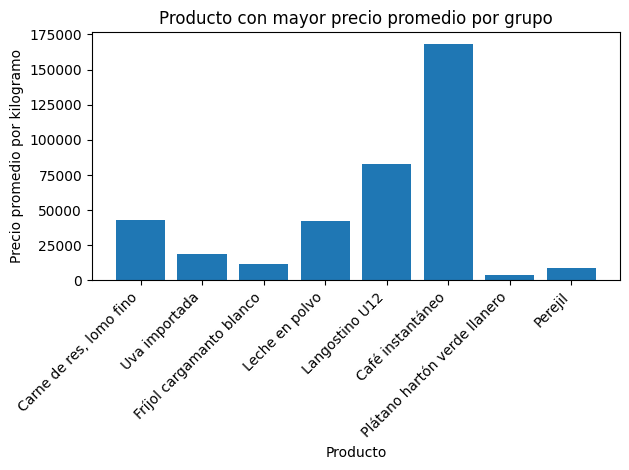

In [ ]:
plt.bar(
    productoCaroDelGrupo['Producto'],
    productoCaroDelGrupo['Precio_Promedio']
)
plt.title('Producto con mayor precio promedio por grupo')
plt.xlabel('Producto')
plt.ylabel('Precio promedio por kilogramo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusiones**: La variable "grupo" es viable para el proceso de estudio en solo un año, cualquiera de esa variable podemos descubrir nuevas variables que pueden ayudar a encontrar los mejores y peores productos segun la frencuencia, el mas caro y el mas barato, realizar un promedio de todos sus precios, todo esto durante un año

###Estudio de la variable "Mercado" para un estudio de un año

1. Como primer acercamiento se necesita saber como se mueven los productos en los distintos mercados mayoristas que se encuentran en la nacion

In [ ]:
df.groupby('Mercado')['Producto'] \
.nunique()\
.sort_values(ascending=False)\
.reset_index(name='Cantidad_Productos')

,Mercado,Cantidad_Productos
0,"Medellín, Central Mayorista de Antioquia",216
1,"Bogotá, D.C., Corabastos",181
2,"Cúcuta, Cenabastos",152
3,"Villavicencio, CAV",139
4,"Ibagué, Plaza La 21",135
...,...,...
77,Nocaima (Cundinamarca),2
78,"San Gil (Santander), panela",2
79,Villeta (Cundinamarca),2
80,Vélez (Santander),2


2. Vamos a encontrar el producto favorito de cada mercado

In [ ]:
productoFavoritoMercado = (
    df.groupby(['Mercado', 'Producto'])
      .size()
      .reset_index(name='Cantidad')
      .sort_values(['Mercado', 'Cantidad'], ascending=[True, False])
      .groupby('Mercado')
      .head(1)
)
productoFavoritoMercado

,Mercado,Producto,Cantidad
2,Ancuya (Nariño),Panela redonda morena,11
3,Arauca (Arauca),Aguacate papelillo,12
57,"Armenia, Mercar",Aceite de palma,12
176,"Armenia, Retiro",Banano criollo,12
184,"Barranquilla, Barranquillita",Aceite girasol,12
...,...,...,...
4601,"Villavicencio, CAV",Aceite vegetal mezcla,12
4740,Villeta (Cundinamarca),Panela cuadrada morena,12
4742,Vélez (Santander),Panela cuadrada blanca,12
4744,Yolombó (Antioquia),Panela redonda morena,12


Y si se desea un mercado en especifico

In [ ]:
mercadoSeleccionado = 'Cali, Santa Elena'
ProductoEspecificoMercado = (
    df[df['Mercado'] == mercadoSeleccionado]['Producto']
      .value_counts()
)
ProductoEspecificoMercado.head(5)

,count
Producto,
Ahuyama,12
Ajo importado,12
Apio,12
Arveja verde en vaina pastusa,12
Brócoli,12


3. Que tal si separamos los mercados de las cuidades

-> Las ciudades que no tengan mercados mayoristas se marcaran igual, ejemplo Yopal (Casanare) => participara para ambos campos como cuidad y mercado

In [ ]:
import numpy as np

In [ ]:
df[['Ciudad', 'NombreMercado']] = (
    df['Mercado']
    .str.rsplit(',', n=1, expand=True)
)
# Casos sin coma: Yopal (Casanare)
df['NombreMercado'] = np.where(
    df['NombreMercado'].isna(),
    df['Ciudad'],
    df['NombreMercado']
)
df['Ciudad'] = df['Ciudad'].str.strip()
df['NombreMercado'] = df['NombreMercado'].str.strip()

In [ ]:
relacion = (
    df[['Ciudad', 'NombreMercado']]
    .drop_duplicates()
    .sort_values(['Ciudad', 'NombreMercado'])
)

display(relacion)

,Ciudad,NombreMercado
4342,Ancuya (Nariño),Ancuya (Nariño)
46,Arauca (Arauca),Arauca (Arauca)
0,Armenia,Mercar
338,Armenia,Retiro
82,Barranquilla,Barranquillita
...,...,...
15,Villavicencio,CAV
4333,Villeta (Cundinamarca),Villeta (Cundinamarca)
4309,Vélez (Santander),Vélez (Santander)
4360,Yolombó (Antioquia),Yolombó (Antioquia)


Ahora busquemos los mercados que se encuentran por cuidad, pongamos como ejemplo la cuidad que puede generar mas problemas a la hora de realizar el analisis Bogotá, D.C. por la coma que presenta antes de D.C

In [ ]:
ciudad = 'Bogotá, D.C.'
df[df['Ciudad'] == ciudad]['NombreMercado'].unique()

array(['Corabastos', 'Paloquemao', 'Plaza España', 'Plaza Las Flores',
       'Carnes barrio María Paz', 'Frigorífico Ble Ltda.',
       'Frigorífico Guadalupe'], dtype=object)

Para comprobar la veracidad de esta medicion, podemos extraer del data_frame original y llamar los mercados que contengan la palabra de bogotá, D.C

In [ ]:
df[df['Mercado'].str.contains('Bogotá', case=False, na=False)] \
  ['Mercado'] \
  .unique()

array(['Bogotá, D.C., Corabastos', 'Bogotá, D.C., Paloquemao',
       'Bogotá, D.C., Plaza España', 'Bogotá, D.C., Plaza Las Flores',
       'Bogotá, D.C., Carnes barrio María Paz',
       'Bogotá, D.C., Frigorífico Ble Ltda.',
       'Bogotá, D.C., Frigorífico Guadalupe',
       'Bogotá, D.C., Frigorífico Ble Ltda,'], dtype=object)

Por las dudas se presento el analisis en la cuidad de cali

In [ ]:
ciudad = 'Cali'
df[df['Ciudad'] == ciudad]['NombreMercado'].unique()

array(['Cavasa', 'Santa Elena', 'La Floresta', 'Siloé', 'Galería Alameda'],
      dtype=object)

In [ ]:
df[df['Mercado'].str.contains('Cali', case=False, na=False)] \
  ['Mercado'] \
  .unique()

array(['Cali, Cavasa', 'Cali, Santa Elena', 'Cali, La Floresta',
       'Cali, Siloé', 'Cali, Galería Alameda'], dtype=object)

Realicemos una comparativa entre esas dos cuidades y su frecuencia de productos

In [ ]:
ciudadA = 'Bogotá, D.C.'
ciudadB = 'Cali'

In [ ]:
comparacionCiudades = (
    df[df['Ciudad'].isin([ciudadA, ciudadB])]
    .groupby('Ciudad')['Producto']
    .nunique()
    .reset_index(name='Cantidad_Productos')
)
comparacionCiudades

,Ciudad,Cantidad_Productos
0,"Bogotá, D.C.",233
1,Cali,149


Y si se grafica

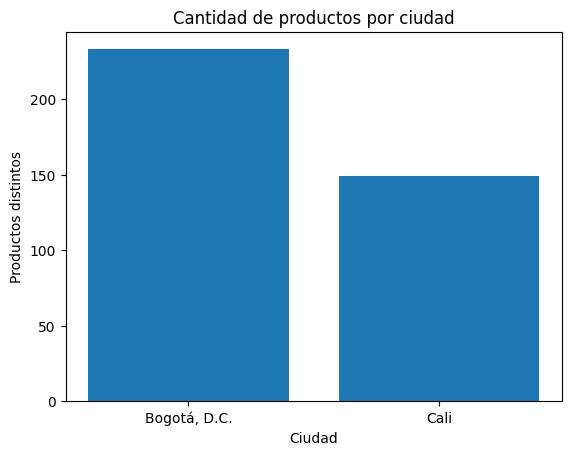

In [ ]:
plt.bar(
    comparacionCiudades['Ciudad'],
    comparacionCiudades['Cantidad_Productos']
)

plt.title('Cantidad de productos por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Productos distintos')

plt.show()

Productos que marcan las diferencias entre esas cuidades y sus comunes

In [ ]:
bogota = set(df[df['Ciudad'] == 'Bogotá, D.C.']['Producto'].unique())
cali = set(df[df['Ciudad'] == 'Cali']['Producto'].unique())

ProductoSoloBogota = bogota - cali
ProductoSoloCali = cali - bogota

print(f"Solo Bogotá: {len(ProductoSoloBogota)}")
print(f"Solo Cali: {len(ProductoSoloCali)}")

Solo Bogotá: 105
Solo Cali: 21


Para los productos comunes

In [ ]:
comunes = bogota.intersection(cali)
print(f"Productos en común: {len(comunes)}")

Productos en común: 128


**Conclusión:** El estudio de este campo nos deja con una posible ampliacion en el dataframe, la cual consiste en separar de "mercado" la cuidad y el mercado mayorista, creando nuevas comparaciones, inclusive se podria agregar un campo adiccional que sea por departamentos, creando un nuevo metodo de agrupacion, ademas con esos campos tenemos un avanico nuevo de comparaciones y determinar cuales gobiernan en esta produccion.

### Estudio de la variable "precio" durante 1 año

Lo **primero** que se debe evaluar de esta variable es que esta en kilogramos (kg) una unidad de medida de masa expecialmente dirrecionada a comerciante pero que el proyecto tambien vamos apoyar al consumidor y por general ellos compran por libras, para ello vamos a seguir la siguiente ecuacion, redondeandola en 2.205 para obtener una mayor exactitutd

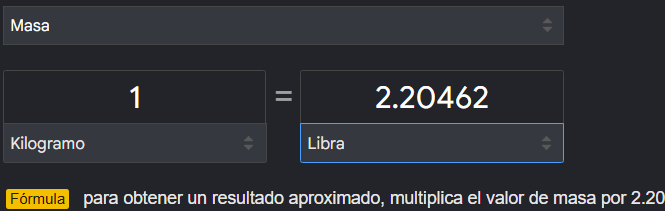

In [ ]:
df['Precio promedio por libra'] = (
    df['Precio promedio por kilogramo*'] / 2.205
).round(2)

In [ ]:
df[
    ['Producto',
     'Precio promedio por kilogramo*',
     'Precio promedio por libra']
]

,Producto,Precio promedio por kilogramo*,Precio promedio por libra
0,Acelga,1508,683.90
1,Acelga,794,360.09
2,Acelga,2005,909.30
3,Acelga,1832,830.84
4,Acelga,2000,907.03
...,...,...,...
54403,Vinagre,1742,790.02
54404,Vinagre,1958,887.98
54405,Vinagre,1437,651.70
54406,Vinagre,1312,595.01


Con esta informacion se podra agregar una nueva columna precio promedio por libra, con la finalidad de publicar el precio de apoyo de cualquier consumidor

Ahora bien, que tal si se compara la diferencia de un producto desde donde comenzo (enero) hasta (diciembre).

In [ ]:
productoEstudiar = 'Naranja Sweet'
productoEnEnero = df[
    (df['Producto'] == productoEstudiar) &
    (df['Fecha'].dt.month == 1)
]['Precio promedio por kilogramo*'].mean().round(2)

productoEnDiciembre = df[
    (df['Producto'] == productoEstudiar) &
    (df['Fecha'].dt.month == 12)
]['Precio promedio por kilogramo*'].mean().round(2)

variacionProducto = (productoEnDiciembre + productoEnEnero).round(2)

print(f"Precio promedio de {productoEstudiar} en enero: ${productoEnEnero}")
print(f"Precio promedio de {productoEstudiar} en diciembre: ${productoEnDiciembre}")
print(f"Variación del precio promedio de {productoEstudiar}: ${variacionProducto}")

Precio promedio de Naranja Sweet en enero: $1842.29
Precio promedio de Naranja Sweet en diciembre: $1932.93
Variación del precio promedio de Naranja Sweet: $3775.22


Es interesante, pero general y si se fija en una sola cuidad, como medellin

para eso, como primer paso se debe investigar si ese producto esta presente en el mercado de esa cuidad

In [ ]:
# Se cambio el producto por que no se encuentra en el mercado
productoEstudiar = 'Carne de cerdo, lomo sin hueso'
ciudad = 'Medellín'
estaEnMercado = (
    (df['Ciudad'] == ciudad) &
    (df['Producto'] == productoEstudiar)
).any()

if estaEnMercado:
    print(f"El producto {productoEstudiar} está presente en el mercado de {ciudad}.")
else:
    print(f"El producto {productoEstudiar} no está presente en el mercado de {ciudad}.")

El producto Carne de cerdo, lomo sin hueso está presente en el mercado de Medellín.


Procedemos a encontrar su variacion

In [ ]:
if estaEnMercado:
  productoEnEneroCiudad = df[
      (df['Ciudad'] == ciudad) &
      (df['Producto'] == productoEstudiar) &
      (df['Fecha'].dt.month == 1)
  ]['Precio promedio por kilogramo*'].mean().round(2)
  productoEnDiciembreCiudad = df[
      (df['Ciudad'] == ciudad) &
      (df['Producto'] == productoEstudiar) &
      (df['Fecha'].dt.month == 12)
      ]['Precio promedio por kilogramo*'].mean().round(2)
  variacionProductoCiudad = (productoEnDiciembreCiudad - productoEnEneroCiudad).round(2)

  print(f"Precio promedio de {productoEstudiar} en enero en {ciudad}: ${productoEnEneroCiudad}")
  print(f"Precio promedio de {productoEstudiar} en diciembre en {ciudad}: ${productoEnDiciembreCiudad}")
  print(f"Variación del precio promedio de {productoEstudiar} en {ciudad}: ${variacionProductoCiudad}")
else:
  print(f"El producto {productoEstudiar} no está presente en el mercado de {ciudad}.")

Precio promedio de Carne de cerdo, lomo sin hueso en enero en Medellín: $24997.0
Precio promedio de Carne de cerdo, lomo sin hueso en diciembre en Medellín: $23800.0
Variación del precio promedio de Carne de cerdo, lomo sin hueso en Medellín: $-1197.0


###PRODUCTOS MAS COMERCIALIZADOS ENTRE TODOS LOS MERCADOS

In [ ]:
productos_mercados = (
    df.groupby('Producto')['Mercado']
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name='Cantidad_Mercados')
)
productos_mercados.head(10)

,Producto,Cantidad_Mercados
0,Tomate de árbol,46
1,Papa criolla limpia,45
2,Pimentón,44
3,Pepino cohombro,42
4,Habichuela,42
5,Lechuga Batavia,42
6,Cilantro,41
7,Lulo,39
8,Plátano hartón verde,38
9,Banano criollo,38


In [ ]:
producto_top = (
    df.groupby('Producto')['Mercado']
      .nunique()
      .idxmax()
)
print(f"Producto más presente: {producto_top}")

Producto más presente: Tomate de árbol


### AJUSTES DE LA VARIABLE DE FECHA PARA MOVERME POR LOS MESES x AÑO (2025-01) => Enero del 2025

In [ ]:
df['AñoMes'] = df['Fecha'].dt.to_period('M')

In [ ]:
df['AñoMes'].value_counts().sort_index()

,count
AñoMes,
2025-01,4493
2025-02,4488
2025-03,4491
2025-04,4503
2025-05,4519
2025-06,4541
2025-07,4569
2025-08,4543
2025-09,4555


In [ ]:
meses = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

df['AñoMesTexto'] = (
    df['Fecha'].dt.year.astype(str)
    + '-'
    + df['Fecha'].dt.month.map(meses)
)

### CALCULO DEL PRECIO PROMEDIO POR MES DEL PRODUCTO MAS PRESENTE ENTRE ESOS MERCADOS


In [ ]:
serie_producto = (
    df[df['Producto'] == producto_top]
      .groupby('AñoMes')['Precio promedio por kilogramo*']
      .mean()
      .round(2)
      .reset_index()
)

In [ ]:
serie_producto

,AñoMes,Precio promedio por kilogramo*
0,2025-01,2600.84
1,2025-02,2319.89
2,2025-03,2038.27
3,2025-04,2122.29
4,2025-05,2424.42
5,2025-06,3676.13
6,2025-07,4183.47
7,2025-08,3840.60
8,2025-09,3140.49
9,2025-10,2870.13


### GRAFICA DEL PRODUCTO MAS COMERCIALIZADO A TRAVEZ DE LOS MESES

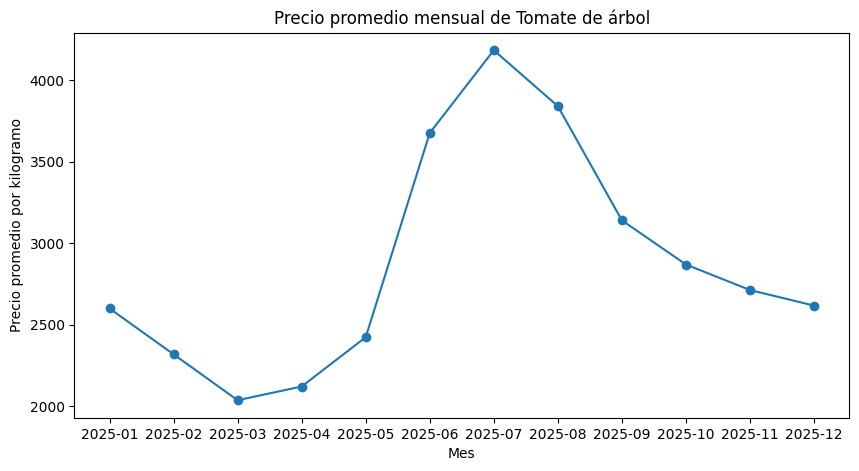

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    serie_producto['AñoMes'].astype(str),
    serie_producto['Precio promedio por kilogramo*'],
    marker='o'
)
plt.title(f'Precio promedio mensual de {producto_top}')
plt.xlabel('Mes')
plt.ylabel('Precio promedio por kilogramo')
plt.show()

Con esta grafica podemos comprender el producto que se comercializa mas a nivel general entre todos los mercados mayoristas de la nación, sin embargo tambien lo podes analizar segun un mercado especifico, primero debemos validar si ese producto se encuentra en el mercado y luego ver si se reproduce en los meses del año de prueba

### EJEMPLO DE ESTUDIO DE UN PRODUCTO EN UN  MERCADO X (Bucaramanga, Centroabastos)

Se crea una variable donde cualquier persona puede escoger el mercado mayorista deseado

In [ ]:
mercadoX = 'Bucaramanga, Centroabastos'

Validacion si el producto existe

In [ ]:
(
    (df['Producto'] == producto_top) &
    (df['Mercado'] == mercadoX)
).any()

np.True_

###Se realiza la consulta del producto en el mercado X a travez del tiempo

In [ ]:
serie_mercadoX = (
    df[
        (df['Producto'] == producto_top) &
        (df['Mercado'] == mercadoX)
    ]
    .groupby('AñoMes', as_index=False)
    ['Precio promedio por kilogramo*']
    .mean()
    .round(2)
)

serie_mercadoX

,AñoMes,Precio promedio por kilogramo*
0,2025-01,2603.0
1,2025-02,1934.0
2,2025-03,1720.0
3,2025-04,2207.0
4,2025-05,2660.0
5,2025-06,4244.0
6,2025-07,4500.0
7,2025-08,3878.0
8,2025-09,2766.0
9,2025-10,2799.0


###AGRUACION de cantidad de productos X mercado X AÑOMES (ej: 2025-01)

In [ ]:
resumen_productos = (
    df.groupby(['AñoMes', 'Producto'])
      ['Precio promedio por kilogramo*']
      .mean()
      .reset_index()
)
resumen_productos

,AñoMes,Producto,Precio promedio por kilogramo*
0,2025-01,Aceite de palma,7440.000000
1,2025-01,Aceite girasol,15045.875000
2,2025-01,Aceite soya,8451.500000
3,2025-01,Aceite vegetal mezcla,8594.481481
4,2025-01,Acelga,2110.941176
...,...,...,...
4150,2025-12,Zanahoria larga vida,1068.785714
4151,2025-12,Zapote,3670.750000
4152,2025-12,Ñame criollo,2638.500000
4153,2025-12,Ñame diamante,1915.000000


# CREACION DE PARQUET

In [ ]:
import pandas as pd


In [ ]:
parqued = pd.read_parquet('sipsa_consolidado_2025.parquet')
parqued

,fecha,grupo,producto,mercado,precio_kg
0,2013-01-01,CARNES,"CARNE DE RES, PALETERO","BUCARAMANGA, FRIGORIFICOS",11000.0
1,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"MANIZALES, CENTRO GALERIAS",14372.0
2,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"MEDELLIN, CENTRAL MAYORISTA DE ANTIOQUIA",10892.0
3,2013-01-01,PROCESADOS,MAYONESA DOY PACK,PALMIRA (VALLE DEL CAUCA),13167.0
4,2013-01-01,PROCESADOS,MAYONESA DOY PACK,"PASTO, EL POTRERILLO",12647.0
...,...,...,...,...,...
721273,2025-12-01,FRUTAS,MANZANA VERDE IMPORTADA,"BOGOTA, D.C., CORABASTOS",9520.0
721274,2025-12-01,FRUTAS,MANZANA VERDE IMPORTADA,"ARMENIA, MERCAR",9129.0
721275,2025-12-01,FRUTAS,MANZANA VERDE IMPORTADA,ARAUCA (ARAUCA),11752.0
721276,2025-12-01,FRUTAS,MANZANA VERDE IMPORTADA,"CALI, SANTA ELENA",8684.0


In [ ]:
# convertir el parquet en un xlsx
parqued.to_excel('sipsa_consolidado_2025.xlsx', index=False)

# CREACION DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


###ACCIONES ANTES (Carga de dataset completo y ajuste de la variable fecha)

In [20]:
df = pd.read_excel('/content/proyecto_ciencia_datos/data/Unificados/SIPSA_2013_2026_FINAL_I.xlsx')
df

,Fecha,Grupo,Producto,Mercado,Departamento,Código departamento,Municipio,Código municipio,Precio promedio por kilogramo*,Circulación
0,2013-01-01,"tuberculos, raices y platanos",papa unica,"barranquilla, granabastos",atlantico,8,barranquilla,8001,435.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, granabastos",atlantico,8,barranquilla,8001,3067.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico ble ltda","bogota, d.c.",11,"bogota, d.c.",11001,2967.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
...,...,...,...,...,...,...,...,...,...,...
744437,2026-05-01,frutas,manzana royal gala importada,"bogota, d.c., corabastos","bogota, d.c.",11,"bogota, d.c.",11001,7653.0,si
744438,2026-05-01,frutas,manzana royal gala importada,"armenia, mercar",quindio,63,armenia,63001,8086.0,si
744439,2026-05-01,frutas,manzana royal gala importada,arauca (arauca),arauca,81,arauca,81001,9667.0,si
744440,2026-05-01,frutas,mango comun,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,3900.0,si


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744442 entries, 0 to 744441
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Fecha                           744442 non-null  datetime64[ns]
 1   Grupo                           744442 non-null  object        
 2   Producto                        744442 non-null  object        
 3   Mercado                         744442 non-null  object        
 4   Departamento                    744442 non-null  object        
 5   Código departamento             744442 non-null  int64         
 6   Municipio                       744442 non-null  object        
 7   Código municipio                744442 non-null  int64         
 8   Precio promedio por kilogramo*  744442 non-null  float64       
 9   Circulación                     744442 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
me

In [22]:
import ipywidgets as widgets
from IPython.display import display

In [23]:
departamentos = sorted(df['Departamento'].dropna().unique())
departamentos

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [24]:
departamentos = ['Colombia'] + departamentos

In [25]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('Colombia', 'antioquia', 'arauca'…

In [26]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: antioquia


In [27]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[df['Departamento'] == departamento]['Municipio']
        .dropna()
        .unique()
        .tolist()
    )
    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    display(dropdown_municipio)
else:
    print("No es necesario seleccionar un municipio.")

Dropdown(description='Municipio:', layout=Layout(width='400px'), options=('el carmen de viboral', 'el santuari…

In [28]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

Municipio seleccionado: medellin


In [29]:
if departamento.lower() == 'colombia':
    mercados = sorted(
        df['Mercado']
        .dropna()
        .unique()
        .tolist()
    )
elif departamento.lower() == 'bogota, d.c.':
    mercados = sorted(
        df[df['Departamento'] == departamento]['Mercado']
        .dropna()
        .unique()
        .tolist()
    )
else:
    municipio = dropdown_municipio.value
    mercados = sorted(
        df[df['Municipio'] == municipio]['Mercado']
        .dropna()
        .unique()
        .tolist()
    )
dropdown_mercado = widgets.Dropdown(
    options=mercados,
    description='Mercado:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_mercado)

Dropdown(description='Mercado:', layout=Layout(width='400px'), options=('medellin, central mayorista de antioq…

In [30]:
mercado = dropdown_mercado.value
print("Mercado seleccionado:", mercado)

Mercado seleccionado: medellin, central mayorista de antioquia


In [31]:
mercado = dropdown_mercado.value

productos = sorted(
    df[df['Mercado'] == mercado]['Producto']
    .dropna()
    .unique()
    .tolist()
)

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('aceite de palma', 'aceite girasol', …

In [183]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: repollo morado


In [184]:
serie = (
    df[
        (df['Mercado'] == mercado) &
        (df['Producto'] == producto)
    ][['Fecha', 'Precio promedio por kilogramo*']]
    .copy()
)

serie = serie.sort_values('Fecha')
serie.set_index('Fecha', inplace=True)

serie.rename(
    columns={'Precio promedio por kilogramo*':'precio'},
    inplace=True
)

In [185]:
# Completar la frecuencia mensual
serie = serie.asfreq("MS")

# Interpolación basada en el tiempo
serie["precio"] = serie["precio"].interpolate(method="linear")

In [186]:
print("Información de la serie")
print("-" * 40)
print(f"Cantidad de registros: {len(serie)}")
print(f"Fecha inicial: {serie.index.min().date()}")
print(f"Fecha final: {serie.index.max().date()}")
print("\nValores nulos:")
print(serie.isnull().sum())

Información de la serie
----------------------------------------
Cantidad de registros: 161
Fecha inicial: 2013-01-01
Fecha final: 2026-05-01

Valores nulos:
precio    0
dtype: int64


In [187]:
import matplotlib.pyplot as plt

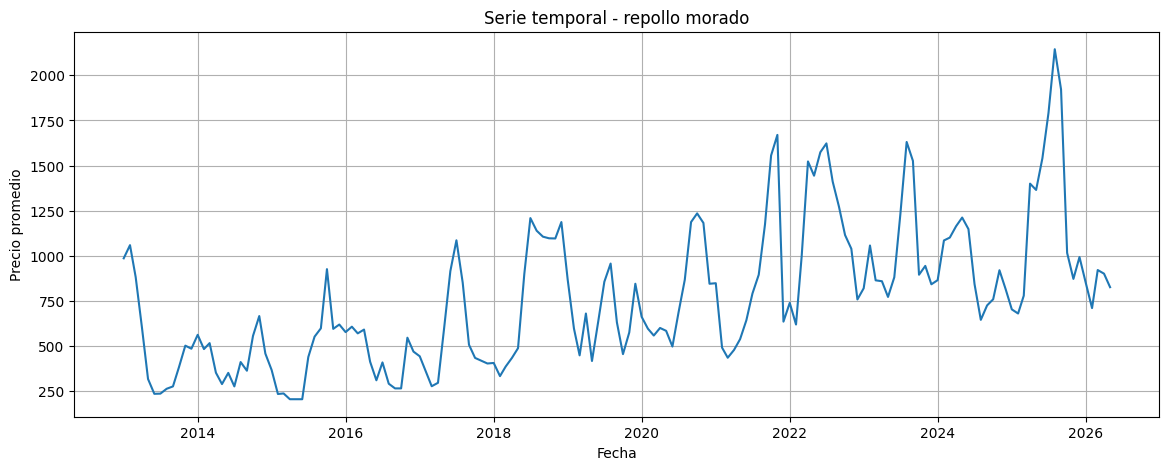

In [188]:
plt.figure(figsize=(14,5))
plt.plot(serie['precio'])
plt.title(f'Serie temporal - {producto}')
plt.xlabel('Fecha')
plt.ylabel('Precio promedio')
plt.grid(True)
plt.show()

In [189]:
from statsmodels.tsa.stattools import adfuller
print("=" * 60)
print("FASE 3 - ANÁLISIS DE LA SERIE")
print("=" * 60)
serie_modelo = serie['precio'].copy()
d = 0
max_d = 2
while d <= max_d:
    resultado = adfuller(serie_modelo)
    adf = resultado[0]
    pvalue = resultado[1]
    print(f"\nPrueba ADF con d = {d}")
    print(f"ADF      : {adf:.4f}")
    print(f"p-value  : {pvalue:.6f}")
    if pvalue < 0.05:
        print("\n✅ La serie es estacionaria.")
        print(f"Se utilizará d = {d}")
        break
    else:
        print("⚠️ La serie NO es estacionaria.")
        print("Aplicando diferenciación...")
        serie_modelo = serie_modelo.diff().dropna()
        d += 1
if d > max_d:

    print("\n❌ No fue posible lograr estacionariedad con las diferenciaciones permitidas.")

FASE 3 - ANÁLISIS DE LA SERIE

Prueba ADF con d = 0
ADF      : -4.5702
p-value  : 0.000147

✅ La serie es estacionaria.
Se utilizará d = 0


In [190]:
from statsmodels.tsa.stattools import acf

print("=" * 60)
print("FASE 4 - DETECCIÓN DE ESTACIONALIDAD")
print("=" * 60)

# Calcula la autocorrelación hasta el rezago 12
acf_values = acf(serie_modelo, nlags=12)

lag12 = acf_values[12]

print(f"Autocorrelación (lag 12): {lag12:.4f}")

# Umbral inicial
if abs(lag12) >= 0.30:
    estacional = True
    print("\n✅ Se detectó estacionalidad anual.")
    print("Modelo recomendado: SARIMA")
else:
    estacional = False
    print("\n✅ No se detectó estacionalidad significativa.")
    print("Modelo recomendado: ARIMA")

FASE 4 - DETECCIÓN DE ESTACIONALIDAD
Autocorrelación (lag 12): 0.3647

✅ Se detectó estacionalidad anual.
Modelo recomendado: SARIMA


In [191]:
!pip install pmdarima

In [192]:
from pmdarima import auto_arima

In [193]:
meses_prueba = 12
train = serie.iloc[:-meses_prueba]
test = serie.iloc[-meses_prueba:]
print(f"Registros de entrenamiento: {len(train)} meses ({train.index[0].strftime('%Y-%m')} a {train.index[-1].strftime('%Y-%m')})")
print(f"Registros de prueba: {len(test)} meses ({test.index[0].strftime('%Y-%m')} a {test.index[-1].strftime('%Y-%m')})")

Registros de entrenamiento: 149 meses (2013-01 a 2025-05)
Registros de prueba: 12 meses (2025-06 a 2026-05)


In [194]:
print("=" * 60)
print("FASE 5 - OPTIMIZACIÓN DEL MODELO")
print("=" * 60)

modelo_auto = auto_arima(
    train['precio'],
    seasonal=True,
    m=12,
    # Deja que auto_arima determine d y D de forma coherente
    d=None,              # Permite que el test KPSS/ADF elija d (0 o 1)
    D=None,              # Permite que el test Canova-Hansen/OCSB elija D (0 o 1)
    max_d=1,
    max_D=1,
    # Obliga a probar términos AR y MA
    start_p=1, max_p=3,
    start_q=1, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    stepwise=False,      # Búsqueda Grid Search completa
    n_jobs=-1,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)
print(modelo_auto.summary())

FASE 5 - OPTIMIZACIÓN DEL MODELO

Best model:  ARIMA(3,1,0)(0,0,1)[12] intercept
Total fit time: 49.615 seconds
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  149
Model:             SARIMAX(3, 1, 0)x(0, 0, [1], 12)   Log Likelihood                -988.004
Date:                              Wed, 22 Jul 2026   AIC                           1988.009
Time:                                      01:04:14   BIC                           2005.992
Sample:                                  01-01-2013   HQIC                          1995.316
                                       - 05-01-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [195]:
print("Modelo seleccionado:")

print(modelo_auto.order)

print(modelo_auto.seasonal_order)

Modelo seleccionado:
(3, 1, 0)
(0, 0, 1, 12)


In [196]:
print(pd.infer_freq(serie.index))

MS


In [197]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
print("=" * 60)
print("FASE 7 - ENTRENAMIENTO DEL MODELO")
print("=" * 60)
modelo = SARIMAX(
    train['precio'],
    order=modelo_auto.order,
    seasonal_order=modelo_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_fit = modelo.fit(disp=False)

print("Modelo entrenado correctamente.")
print(f"Modelo: SARIMA{modelo_auto.order}{modelo_auto.seasonal_order}")

FASE 7 - ENTRENAMIENTO DEL MODELO
Modelo entrenado correctamente.
Modelo: SARIMA(3, 1, 0)(0, 0, 1, 12)


In [198]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(
    train,
    order=modelo_auto.order,
    seasonal_order=modelo_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_fit = modelo.fit(disp=False)

In [199]:
predicciones = modelo_fit.forecast(steps=len(test))

In [200]:
modelo_final = SARIMAX(
    serie['precio'],
    order=modelo_auto.order,
    seasonal_order=modelo_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = modelo_final.fit(disp=False)

In [201]:
forecast = modelo_final.forecast(
    steps=12
)

In [202]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ===========================
# FASE 8 - EVALUACIÓN
# ===========================

mae = mean_absolute_error(test['precio'], predicciones)

rmse = np.sqrt(
    mean_squared_error(test['precio'], predicciones)
)

mape = np.mean(
    np.abs((test['precio'] - predicciones) / test['precio'])
) * 100

print("=" * 60)
print("FASE 8 - EVALUACIÓN DEL MODELO")
print("=" * 60)

print(f"Modelo seleccionado : SARIMA{modelo_auto.order}{modelo_auto.seasonal_order}")
print(f"MAE                 : {mae:.2f}")
print(f"RMSE                : {rmse:.2f}")
print(f"MAPE                : {mape:.2f}%")

if mape < 10:
    print("\nExcelente capacidad predictiva.")
elif mape < 20:
    print("\nBuen desempeño del modelo.")
elif mape < 30:
    print("\nDesempeño aceptable.")
else:
    print("\nEl modelo requiere optimización.")

FASE 8 - EVALUACIÓN DEL MODELO
Modelo seleccionado : SARIMA(3, 1, 0)(0, 0, 1, 12)
MAE                 : 410.94
RMSE                : 529.57
MAPE                : 31.42%

El modelo requiere optimización.


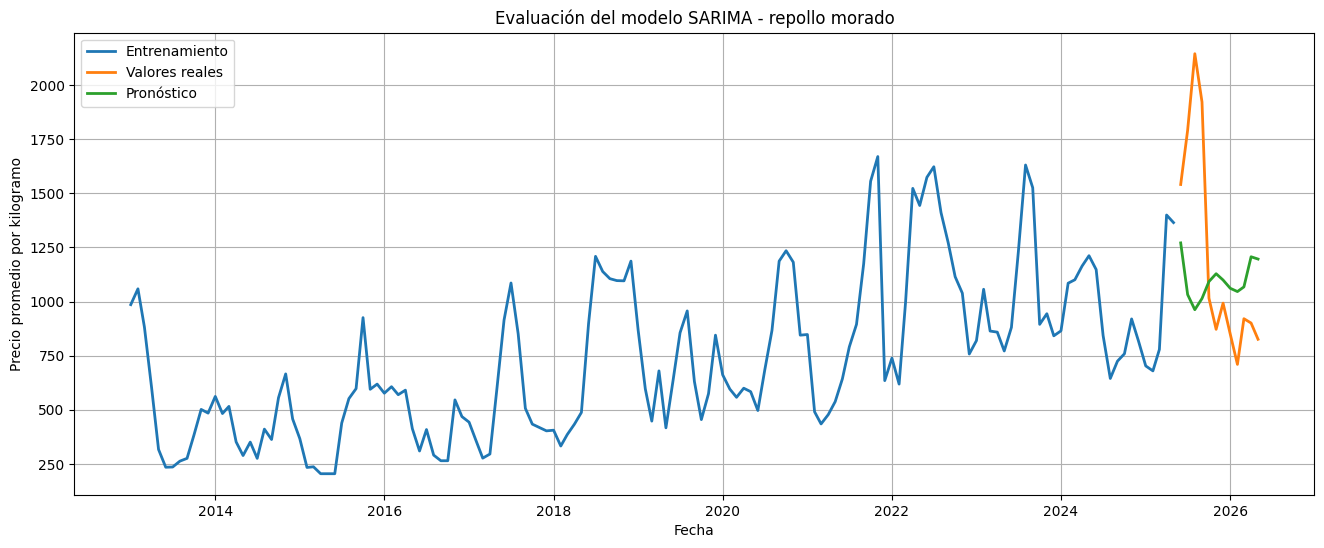

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(train.index, train['precio'],
         label="Entrenamiento", linewidth=2)

plt.plot(test.index, test['precio'],
         label="Valores reales", linewidth=2)

plt.plot(test.index, predicciones,
         label="Pronóstico", linewidth=2)

plt.title(f"Evaluación del modelo SARIMA - {producto}")

plt.xlabel("Fecha")
plt.ylabel("Precio promedio por kilogramo")

plt.grid(True)

plt.legend()

plt.show()